# Porto Taxi Trajectory — Exploratory Data Analysis
TDT4225 Assignment 2, Part 1

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime, math, os
from dotenv import load_dotenv

load_dotenv()

PATH = os.getenv("PORTO_CSV_PATH")
CHUNKSIZE = 500_000


In [9]:
total_rows = 0
call_type_counts = {}
day_type_counts = {}
missing_data_counts = {}
taxi_trip_counts = {}
poly_len_hist = np.zeros(201, dtype=np.int64)
poly_len_stats = {"sum": 0, "sq_sum": 0, "min": None, "max": None, "empty": 0, "lt3": 0, "count": 0}
month_counts = {}
ts_min, ts_max = None, None
trip_id_seen = set()
dup_trip_id_rows = 0
origin_call_null_by_calltype = {}
origin_stand_null_by_calltype = {}

def poly_len(s):
    if not isinstance(s, str) or s == "[]":
        return 0
    return s.count("],[") + 1

for i, chunk in enumerate(pd.read_csv(PATH, chunksize=CHUNKSIZE)):
    total_rows += len(chunk)

    for col, counter in [("CALL_TYPE", call_type_counts), ("DAY_TYPE", day_type_counts), ("MISSING_DATA", missing_data_counts)]:
        vc = chunk[col].value_counts(dropna=False)
        for k, v in vc.items():
            counter[str(k)] = counter.get(str(k), 0) + int(v)

    vc_taxi = chunk["TAXI_ID"].value_counts()
    for tid, v in vc_taxi.items():
        taxi_trip_counts[tid] = taxi_trip_counts.get(tid, 0) + int(v)

    for ct in chunk["CALL_TYPE"].unique():
        sub = chunk[chunk["CALL_TYPE"] == ct]
        oc = origin_call_null_by_calltype.setdefault(ct, [0, 0])
        oc[0] += int(sub["ORIGIN_CALL"].isna().sum()); oc[1] += len(sub)
        os_ = origin_stand_null_by_calltype.setdefault(ct, [0, 0])
        os_[0] += int(sub["ORIGIN_STAND"].isna().sum()); os_[1] += len(sub)

    lens = chunk["POLYLINE"].apply(poly_len)
    poly_len_stats["count"] += len(lens)
    poly_len_stats["sum"] += int(lens.sum())
    poly_len_stats["sq_sum"] += int((lens**2).sum())
    cmin, cmax = int(lens.min()), int(lens.max())
    poly_len_stats["min"] = cmin if poly_len_stats["min"] is None else min(poly_len_stats["min"], cmin)
    poly_len_stats["max"] = cmax if poly_len_stats["max"] is None else max(poly_len_stats["max"], cmax)
    poly_len_stats["empty"] += int((lens == 0).sum())
    poly_len_stats["lt3"] += int((lens < 3).sum())

    clipped = lens.clip(upper=200)
    for v in clipped.value_counts().items():
        poly_len_hist[int(v[0])] += int(v[1])

    tmin, tmax = int(chunk["TIMESTAMP"].min()), int(chunk["TIMESTAMP"].max())
    ts_min = tmin if ts_min is None else min(ts_min, tmin)
    ts_max = tmax if ts_max is None else max(ts_max, tmax)

    months = chunk["TIMESTAMP"].apply(lambda t: datetime.datetime.utcfromtimestamp(int(t)).strftime("%Y-%m"))
    for m, v in months.value_counts().items():
        month_counts[m] = month_counts.get(m, 0) + int(v)

    for tid in chunk["TRIP_ID"].tolist():
        if tid in trip_id_seen:
            dup_trip_id_rows += 1
        else:
            trip_id_seen.add(tid)

    print(f"chunk {i} processed, rows so far: {total_rows}")

mean_len = poly_len_stats["sum"] / poly_len_stats["count"]
std_len = math.sqrt(poly_len_stats["sq_sum"] / poly_len_stats["count"] - mean_len**2)


/var/folders/vw/s1y1tk491vs0wxp7cg76k3j80000gn/T/ipykernel_70035/3322267605.py:57: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  months = chunk["TIMESTAMP"].apply(lambda t: datetime.datetime.utcfromtimestamp(int(t)).strftime("%Y-%m"))


chunk 0 processed, rows so far: 500000


/var/folders/vw/s1y1tk491vs0wxp7cg76k3j80000gn/T/ipykernel_70035/3322267605.py:57: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  months = chunk["TIMESTAMP"].apply(lambda t: datetime.datetime.utcfromtimestamp(int(t)).strftime("%Y-%m"))


chunk 1 processed, rows so far: 1000000


/var/folders/vw/s1y1tk491vs0wxp7cg76k3j80000gn/T/ipykernel_70035/3322267605.py:57: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  months = chunk["TIMESTAMP"].apply(lambda t: datetime.datetime.utcfromtimestamp(int(t)).strftime("%Y-%m"))


chunk 2 processed, rows so far: 1500000


/var/folders/vw/s1y1tk491vs0wxp7cg76k3j80000gn/T/ipykernel_70035/3322267605.py:57: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  months = chunk["TIMESTAMP"].apply(lambda t: datetime.datetime.utcfromtimestamp(int(t)).strftime("%Y-%m"))


chunk 3 processed, rows so far: 1710670


In [3]:
print(f"Total rows: {total_rows}")
print(f"Unique taxis: {len(taxi_trip_counts)}")
print(f"Unique trip_ids: {len(trip_id_seen)}  (duplicate rows: {dup_trip_id_rows})")
print(f"CALL_TYPE: {call_type_counts}")
print(f"DAY_TYPE: {day_type_counts}")
print(f"MISSING_DATA: {missing_data_counts}")
print(f"Polyline length: mean={mean_len:.2f}, std={std_len:.2f}, min={poly_len_stats['min']}, max={poly_len_stats['max']}")
print(f"Empty polylines: {poly_len_stats['empty']}")
print(f"Trips with <3 points (invalid): {poly_len_stats['lt3']}")
print(f"Date range: {datetime.datetime.utcfromtimestamp(ts_min)} -> {datetime.datetime.utcfromtimestamp(ts_max)}")
print(f"ORIGIN_CALL null by call_type: {origin_call_null_by_calltype}")
print(f"ORIGIN_STAND null by call_type: {origin_stand_null_by_calltype}")


Total rows: 1710670
Unique taxis: 448
Unique trip_ids: 1710589  (duplicate rows: 81)
CALL_TYPE: {'B': 817881, 'C': 528019, 'A': 364770}
DAY_TYPE: {'A': 1710670}
MISSING_DATA: {'False': 1710660, 'True': 10}
Polyline length: mean=48.76, std=45.65, min=0, max=3881
Empty polylines: 5901
Trips with <3 points (invalid): 43904
Date range: 2013-07-01 00:00:53 -> 2014-06-30 23:59:56
ORIGIN_CALL null by call_type: {'C': [528019, 528019], 'B': [817881, 817881], 'A': [0, 364770]}
ORIGIN_STAND null by call_type: {'C': [528019, 528019], 'B': [11302, 817881], 'A': [364770, 364770]}


/var/folders/vw/s1y1tk491vs0wxp7cg76k3j80000gn/T/ipykernel_70035/180360124.py:10: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  print(f"Date range: {datetime.datetime.utcfromtimestamp(ts_min)} -> {datetime.datetime.utcfromtimestamp(ts_max)}")


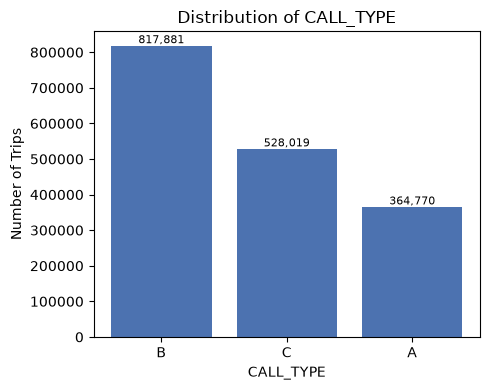

In [10]:
labels = list(call_type_counts.keys())
values = [call_type_counts[k] for k in labels]
plt.figure(figsize=(5,4))
plt.bar(labels, values, color="#4C72B0")
plt.title("Distribution of CALL_TYPE")
plt.xlabel("CALL_TYPE"); plt.ylabel("Number of Trips")
for i, v in enumerate(values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig("figures/call_type_dist.png", dpi=150)
plt.show()


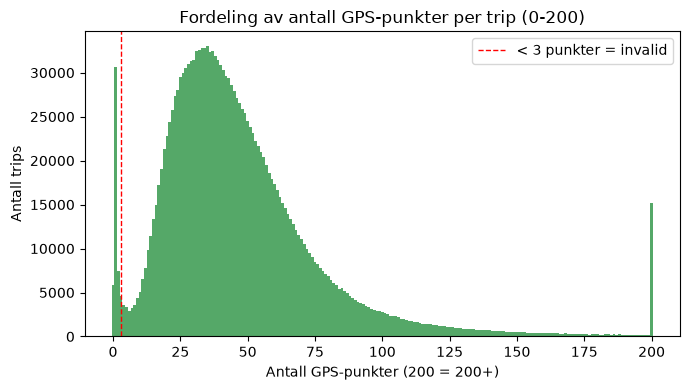

In [ ]:
plt.figure(figsize=(7,4))
plt.bar(range(201), poly_len_hist, width=1.0, color="#55A868")
plt.title("Distribution of Polyline Lengths (0-200)")
plt.xlabel("Number of GPS Points (200 = 200+)"); plt.ylabel("Number of Trips")
plt.axvline(3, color="red", linestyle="--", linewidth=1, label="< 3 points = invalid")
plt.legend()
plt.tight_layout()
plt.savefig("figures/polyline_length_hist.png", dpi=150)
plt.show()


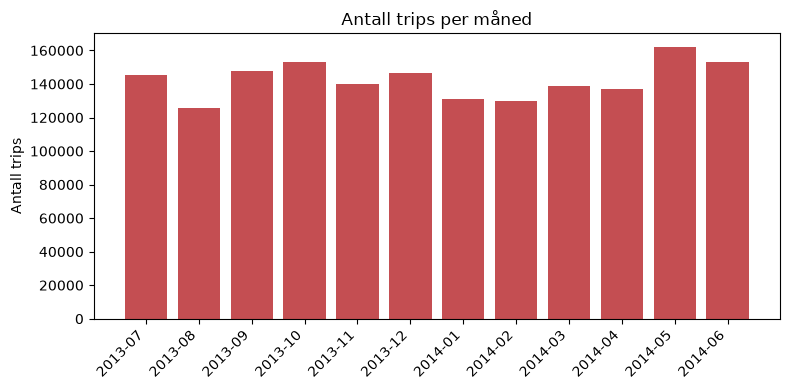

In [ ]:
months_sorted = sorted(month_counts.keys())
plt.figure(figsize=(8,4))
plt.bar(months_sorted, [month_counts[m] for m in months_sorted], color="#C44E52")
plt.title("Number of Trips per Month")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.savefig("figures/trips_per_month.png", dpi=150)
plt.show()

In [ ]:
trip_counts_arr = np.array(list(taxi_trip_counts.values()))
plt.figure(figsize=(6,4))
plt.hist(trip_counts_arr, bins=40, color="#8172B2")
plt.title("Distribution of Number of Trips per Taxi")
plt.xlabel("Number of Trips"); plt.ylabel("Number of Taxies")
plt.tight_layout()
plt.savefig("figures/trips_per_taxi_hist.png", dpi=150)
plt.show()


## Duplicate TRIP_IDs
Se egen undersøkelse: 80 TRIP_ID-verdier forekommer >1 gang (81 duplikate rader totalt).
Årsak: TRIP_ID er generert som TIMESTAMP + TAXI_ID, så to ulike trips med samme
taxi som starter i samme sekund kolliderer. 78 av 80 grupper er reelt ulike trips
(ulik CALL_TYPE/POLYLINE), mens 2 grupper er eksakte duplikatrader.

In [ ]:
seen_ids = set()
dup_ids = set()
for chunk in pd.read_csv(PATH, chunksize=CHUNKSIZE, dtype={"TRIP_ID": str}):
    vc = chunk["TRIP_ID"].value_counts()
    for tid, count in vc.items():
        if tid in seen_ids or count > 1:
            dup_ids.add(tid)
        seen_ids.add(tid)
print(f"Number of TRIP_IDs that appear >1 time: {len(dup_ids)}")


Antall trip_id som forekommer >1 gang: 80
